# Instructions

- Exam 2 is worth **99 points**. 
- Please strive for clarity and organization.
- **AI Usage**:
   - The use of AI is strictly **prohibited** for both conceptual and Python exercises.
- **Due Date: November 21, 2025, by 11:59 PM.**

# Exercise 1 (20 points) 

Please state **True** or **False** for the below statements.

- (a) Cosine similarity is a distance metric, and a score of 1 indicates that two vectors are in opposite orientation (unrelated). 

- (b) The Silhouette Coefficient is a clustering evaluation metric where a score closer to -1 indicates dense, well-separated clusters. 

- (c) Regular expressions are well-suited for extracting highly complex and loosely structured data from text, despite the potential complexity of the patterns. 

- (d) The Retrieval-Augmented Generation (RAG) approach makes a dialogue model more informative by relying solely on the training data it was initially given. 

- (e) Word embeddings can be used as input features for tasks like sentiment analysis, named entity recognition, and machine translation. 

- (f) BERT is a unidirectional model, meaning it learns contextual relationships between words by processing text only from left-to-right. 

- (g) Lexicon-based sentiment models like VADER and TextBlob are generally immune to misjudging sarcasm and context because they use probabilistic methods built on large corpora.

- (h) Word embeddings, such as Word2Vec and GloVe, capture semantic relationships between words and can improve text classification performance. 

- (i) Named Entity Recognition (NER) is a task in NLP that involves identifying specific entities in text, such as names, dates, and locations. 

- (j) NER models are not affected by context and always perform equally well regardless of sentence structure. 

a. False

b. False

c. False

d. False

e. True

f. False

g. False

h. True

i. True

j. False

# Exercise 2 (4 points)

Which unsupervised learning technique groups data points based on local density, can automatically detect outliers (noise), and is useful for text datasets with irregular topic boundaries?

- (a) $k$-means clustering
- (b) Agglomerative clustering
- (c) Principal component analysis
- (d) BDSCAN
- (e) None of the above

D

# Exercise 3 (6 points)

Explain the primary motivation for training a custom Named Entity Recognition (NER) model with `spaCy` instead of relying solely on a large, generic pre-trained model like `en_core_web_sm`. Additionally, what are two important practical considerations when designing the training data to prevent catastrophic forgetting?

The primary reason would be for domain specific applications like pharmacutical trials. Pre-trained models are good for PERSON, ORG, and DATE but a custom trained model would be preferred for picking out DRUG_NAME and CONDITION from medical studies. Two important considerations are to include examples of entity types such as DRUG_NAME and CONDITION and also providing examples where there are no entities so the model does not predict entities where there shouldn't be.

# Exercise 4 (4 points)

What is the primary function of Named Entity Recognition (NER)?

- (a) To measure the emotional tone (positive, negative, or neutral) of a sentence.
- (b) To determine the minimum edits required to transform one string into another.
- (c) To identify real-world objects such as persons, organizations, or dates in text.
- (d) To apply precise, rule-based matching for recurring text patterns.
- (e) None of the above.

C

# Exercise 5 (6 points)

Regular expressions (regex) offer a precise, rule-based approach to Information Extraction (IE). Explain what makes regex effective for tasks like extracting emails and URLs , and state why regex can become complex or fail when dealing with loosely structured data.

It is effective because it is very good at following clear structure that can be found in emails and URLs like "address@email.com" and "www.address.com" or with phone numbers with fixed digit formats and number range. It can fail because loosely structered and complex data lacks the patterns that regex requires and any small change in the input can break the pattern structure. 

# Exercise 6 (4 points)

Which Python library is used to generate the interactive, color-coded visualization that shows distances among topics and their key terms for an LDA model?

- (a) Matplotlib
- (b) SpaCy
- (c) WordCloud 
- (d) PyLDAvis
- (e) All of the above

D

# Exercise 7 (5 points)

You have collected data bout 10,000 posts from X (formely known as Twitter) and no other information. Your task is to create a post classification model that categorizes each of the posts in three buckets: `positive`, `negative`, and `neutral`. How would you train the post classification model? Please, be speficic.  

There are a few options to assign labels. The first would be to apply a pre-trained model from Hugging Face, I have used a twitter sentiment model from there in the past. Using this would create sentiment labels for the 10,000 posts collected from X. Another option would be to manually label a small batch of posts and train a classifier to apply to the remaining posts. I would train the model using the following steps. Pre-process the text, generate labels using one of the methods I mentioned to create the labeled dataset, train and fine-tune the model.

# Exercise 8 (4 points)

What is the right order for a text classification model components?

1. Text cleaning
2. Text annotation
3. Model training 
4. Model tuning
5. Text to predictors

- (a) 1, 2, 3, 4, 5
- (b) 1, 3, 4, 2, 5
- (c) 1, 2, 5, 3, 4 
- (d) 1, 3, 4, 5, 2
- (e) 1, 3, 4, 2, 5

C

# Exercise 9 (6 points)

Explain the role of Named Entity Recognition (NER) in NLP. Provide examples of common entity types that NER models aim to identify and discuss one challenge in implementing NER systems.

The role of NER is to identify real world entities in text. Common enity types are PERSON, ORG, and DATE.

# Exercise 10

You are given the `bbc_data.csv` file, which contains news articles in the data column and their categories in the labels column. Use Python to answer the following questions.

### Exercise 10(a)  (2 points)

Using `pandas` read `bbc_data.csv` and create a data-frame called `df`.

In [10]:
import pandas as pd

df = pd.read_csv('bbc_data.csv')
df.head()

,data,labels
0,Musicians to tackle US red tape Musicians gro...,entertainment
1,"U2s desire to be number one U2, who have won ...",entertainment
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment
3,Snicket tops US box office chart The film ada...,entertainment
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment


### Exercise 10(b) (10 points)

Use a Regular Expression (regex) to find all instances of currency amounts (e.g., $1,300, £680, €1.25m) across all articles in the `data` column. The pattern should capture the currency symbol and the number following it. Report the total number of unique currency amounts found in the entire dataset.

In [16]:
import re

pattern = r'([£$€]\s?\d[\d,]*(?:\.\d+)?(?:[mkMK])?)'

matches = df['data'].apply(lambda x: re.findall(pattern, x))

unique_ammounts = set(match for sublist in matches for match in sublist)
print(f"Number of unique currency ammounts: {len(unique_ammounts)}")

Number of unique currency ammounts: 649


### Exercise 10(c) (10 points)

Prepare the text data for an unsupervised clustering task by transforming it into a high-dimensional vector space. Write Python code to:

- Apply the Term Frequency-Inverse Document Frequency (TF-IDF) vectorizer to the text in the data column.
- When fitting the vectorizer, ensure that:
   - Stop words (common English words) are removed.
   - Only terms that appear in a minimum of 5 documents are included (i.e., set `min_df=5`).
- Report the shape of the resulting TF-IDF matrix (Documents × Features).

In [17]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

stopwords = set(stopwords.words('english'))
pronouns = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'])
others = set(['drink', 'now', 'wine', 'flavor', 'flavors'])

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stopwords and word not in pronouns and word not in others]
    return ' '.join(tokens)

df['data_clean'] = df['data'].apply(clean_text)

tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    max_df=0.8,  # Remove words that appear in more than 80% of documents
    min_df=5,    # Remove words that appear in fewer than 5 documents
    stop_words='english'
)

# Fit and transform the cleaned text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['data_clean'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Number of features: {len(tfidf_vectorizer.get_feature_names_out())}')

TF-IDF matrix shape: (2225, 100)
Number of features: 100


### Exercise 10(d) (10 points)

Visually inspect the most important terms within a specific category. Write Python code to:

- Filter the dataset to include only articles belonging to the `tech` category.
- Generate a single string of all the text from these `tech` articles.
- Create a Word Cloud visualization from this text.

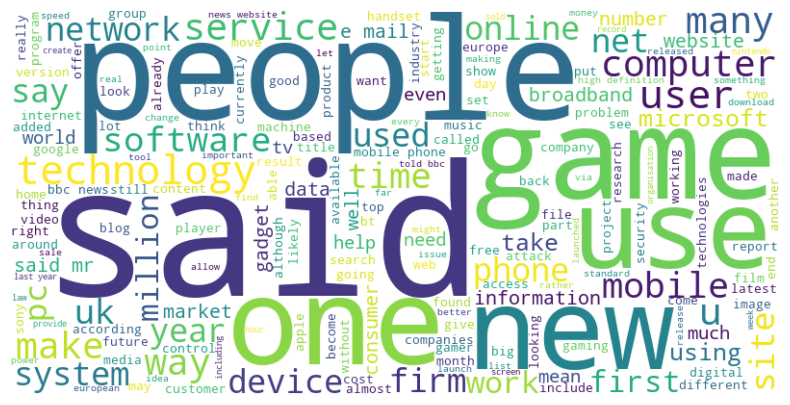

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df_tech = df[df['labels'] == 'tech']

tech_text = ' '.join(df_tech['data_clean'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(tech_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show();


# Exercise 11 (4 points)

What is the fundamental difference between Rule-based Chatbots and AI-based Chatbots?

Rule based chatbots can only respond to specific and anticipated inputs while AI-based chatbots can produce dynamic natural language responses.

# Exercise 12 (4 points)

Which NLP concept is responsible for classifying user input into categories like `"order_pizza"` or `"check_weather"`?

- (a) Tokenization
- (b) Embeddings
- (c) Entity Extraction
- (d) Intent Recognition
- (e) None of the above

D